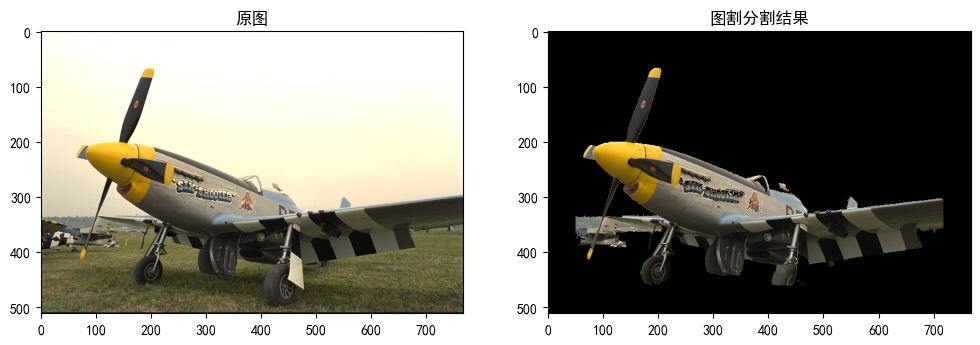

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 读取图像（和.ipynb同目录，文件名完全一致）
img = cv2.imread("kodim20.png")

img_copy = img.copy()
h, w = img.shape[:2]

# 初始化掩模（必须创建）
mask = np.zeros(img.shape[:2], np.uint8)

# 定义前景背景模型（内部使用，固定格式）
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# 手动框选目标区域（根据图像内容调整，示例为居中框选）
rect = (50, 50, w - 100, h - 100)

# 执行图割分割（GrabCut 基于图割实现）
cv2.grabCut(img, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

# 生成分割结果
mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
result = img * mask2[:, :, np.newaxis]

# 结果可视化
plt.figure(figsize=(12, 6))
plt.subplot(121), plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)), plt.title("原图")
plt.subplot(122), plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)), plt.title("图割分割结果")
plt.show()